<a href="https://colab.research.google.com/github/ttoptenn/ttoptenn/blob/circleci-project-setup/use_model_predic_new_smileipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# install conda on google colab
!wget https://repo.anaconda.com/miniconda/Miniconda3-py37_4.8.2-Linux-x86_64.sh
!chmod +x Miniconda3-py37_4.8.2-Linux-x86_64.sh
!bash ./Miniconda3-py37_4.8.2-Linux-x86_64.sh -b -f -p /usr/local
import sys
sys.path.append('/usr/local/lib/python3.7/site-packages/')

--2022-07-31 04:17:55--  https://repo.anaconda.com/miniconda/Miniconda3-py37_4.8.2-Linux-x86_64.sh
Resolving repo.anaconda.com (repo.anaconda.com)... 104.16.130.3, 104.16.131.3, 2606:4700::6810:8303, ...
Connecting to repo.anaconda.com (repo.anaconda.com)|104.16.130.3|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 85055499 (81M) [application/x-sh]
Saving to: ‘Miniconda3-py37_4.8.2-Linux-x86_64.sh.1’

Miniconda3-py37_4.8 100%[===================>]  81.12M   174MB/s    in 0.5s    

2022-07-31 04:17:56 (174 MB/s) - ‘Miniconda3-py37_4.8.2-Linux-x86_64.sh.1’ saved [85055499/85055499]

PREFIX=/usr/local
Unpacking payload ...
Solving environment: - \ | / - \ | / - \ | / failed with initial frozen solve. Retrying with flexible solve.
Solving environment: \ | / - \ | / - \ failed with repodata from current_repodata.json, will retry with next repodata source.
Solving environment: \ | / - \ | / - \ | failed w

In [2]:
!conda install -q -c rdkit rdkit -y # for molecule analysis and visualization

Solving environment: ...working... done

# All requested packages already installed.



In [3]:
!pip install -q chembl_webresource_client # https://www.ebi.ac.uk/chembl/

     |████████████████████████████████| 55 kB 125 kB/s 
     |████████████████████████████████| 60 kB 6.9 MB/s 
     |████████████████████████████████| 596 kB 29.5 MB/s 


In [4]:
pip install tensorflow

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 511.7 MB 5.1 kB/s 
     |████████████████████████████████| 438 kB 41.7 MB/s 
     |████████████████████████████████| 2.4 MB 5.9 MB/s 
     |████████████████████████████████| 14.5 MB 54.0 MB/s 
     |████████████████████████████████| 57 kB 4.7 MB/s 
     |████████████████████████████████| 4.1 MB 52.4 MB/s 
     |████████████████████████████████| 42 kB 889 kB/s 
     |████████████████████████████████| 123 kB 75.4 MB/s 
     |████████████████████████████████| 4.6 MB 50.9 MB/s 
     |████████████████████████████████| 1.6 MB 27.5 MB/s 
     |████████████████████████████████| 1.1 MB 56.6 MB/s 
     |████████████████████████████████| 75 kB 4.0 MB/s 
     |████████████████████████████████| 65 kB 3.9 MB/s 
     |████████████████████████████████| 5.8 MB 68.0 MB/s 
     |████████████████████████████████| 167 kB 71.1 MB/s 
     |████████████████████████████████

In [3]:
# imports
import pandas as pd
import os
from os import path
import zipfile
import glob
import json
import numpy as np
import random
# import tensorflow as tf
import keras
from keras.utils import np_utils
# from tensorflow.keras.models import Model
# from tensorflow.keras import layers
# from tensorflow.keras import initializers
# import matplotlib.pyplot as plt
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, Draw, Descriptors, rdMolDescriptors
from rdkit.Chem.Draw import SimilarityMaps, IPythonConsole
# from chembl_webresource_client.new_client import new_client

# from tensorflow.keras.layers import ReLU, Input, Dense
# from keras.layers import Dropout
# from tensorflow.keras.utils import plot_model
# from matplotlib import pyplot
# from tensorflow.keras.models import Model

#from google.colab import files
from keras.models import Sequential
from keras.models import load_model


# suppress rdkit error/warning messages
from rdkit import rdBase
rdBase.DisableLog('rdApp.error')
rdBase.DisableLog('rdApp.warning')

In [ ]:
# print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

Num GPUs Available:  1


In [ ]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2020 NVIDIA Corporation
Built on Mon_Oct_12_20:09:46_PDT_2020
Cuda compilation tools, release 11.1, V11.1.105
Build cuda_11.1.TC455_06.29190527_0


In [ ]:
!nvidia-smi

Wed Jul 27 01:58:55 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.32.03    Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla T4            Off  | 00000000:00:04.0 Off |                    0 |
| N/A   31C    P8     9W /  70W |      3MiB / 15109MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [4]:
# double letters for one element turned into single letters that are not in the dataset
double_to_single = {'Si':'q', 'Se':'w', 'Cn':'t', 'Sc':'y', 'Cl':'u', 'Sn':'z', 'Br':'x'} 
single_to_double = {'q':'Si', 'w':'Se', 't':'Cn', 'y':'Sc', 'u':'Cl', 'z':'Sn', 'x':'Br'}
elements_with_double_letters = list(double_to_single)

element_set = ['C', '(', '=', 'O', ')','/','\\','.','@', 'N', 'c', '1', '$', '2', '3', '4', '#', 'n', 'F', 'u', '-', '[', 'H', ']', 's', 'o', 'S', 't', '5', '6', '+', 'P', 'I', 'x', 'y', 'q', 'B', 'w', '7', '8', 'e', '9', 'b', 'p', '%', '0', 'z','A','Z','l','T','a','K','g','r','L','i','R','X','M']
n_vocab = len(element_set)
element_to_int = dict(zip(element_set, range(0, n_vocab)))
int_to_element = {v: k for k, v in element_to_int.items()}
sequence_length = 100 

filey = open('/content/pharmaceuticAI_all_compounds.smiles')
structures1 = [line[:-1] for line in filey]
#print("Num Total Samples:", len(structures))
#filey.close()

data = structures1
del structures1
#print("Num Sampled:", num_sampled)
def gen_structs(data):

    structs = []
    for structure in data:
        i = 0
        while i < len(structure):
            try:
                if structure[i] + structure[i+1] in elements_with_double_letters:
                    structs.append(double_to_single[structure[i] + structure[i+1]])
                    i+=2
                else:
                    structs.append(structure[i])
                    i+=1
            except:
                    structs.append(structure[i])
                    i+=1
        structs.append("$") # end token

    return structs

def gen_data(structs):

    network_inp = []

    # create input sequences
    for i in range(0, len(structs) - sequence_length):
        sequence_in = structs[i:i + sequence_length]
        network_inp.append([element_to_int[char] for char in sequence_in])
        
    n_patterns = len(network_inp)

    # reshape the input into a format compatible with CuDNNLSTM layers
    network_inp = np.reshape(network_inp, (n_patterns, sequence_length))

    return network_inp

network_input = gen_data(gen_structs(data))

def get_h_bond_donors(mol):
    idx = 0
    donors = 0
    while idx < len(mol)-1:
        if mol[idx].lower() == "o" or mol[idx].lower() == "n":
            if mol[idx+1].lower() == "h":
                donors+=1
        idx+=1
    return donors

def get_h_bond_acceptors(mol):
    acceptors = 0
    for i in mol:
        if i.lower() == "n" or i.lower() == "o":
            acceptors+=1
    return acceptors

# Lipinski's “Rule of Five” - Constraints in order to maintain drug-like character within the compounds
def rule_of_five(molecule):
    m = Chem.MolFromSmiles(molecule)
    if get_h_bond_donors(molecule) <= 5 and get_h_bond_acceptors(molecule) <= 10 and Descriptors.MolWt(m) <= 500 and Descriptors.MolLogP(m) <= 5:
        return True
    else:
        return False

def similarity(molecule1, molecule2): # fraction of fingerprints the set of two molecules have in common
    m1 = Chem.MolFromSmiles(molecule1)
    bi1 = {}
    fp1 = AllChem.GetMorganFingerprintAsBitVect(m1, radius=2, nBits=2048, bitInfo=bi1)
    fp1_bits1 = fp1.GetOnBits()

    m2 = Chem.MolFromSmiles(molecule2)
    bi2 = {}
    fp2 = AllChem.GetMorganFingerprintAsBitVect(m2, radius=2, nBits=2048, bitInfo=bi2)
    fp2_bits2 = fp2.GetOnBits()

    common = set(fp1_bits1) & set(fp2_bits2)
    combined = set(fp1_bits1) | set(fp2_bits2)

    return len(common)/len(combined) # recreation of DataStructs.TanimotoSimilarity

def similarity(molecule1, molecule2): # fraction of fingerprints the set of two molecules have in common
    m1 = Chem.MolFromSmiles(molecule1)
    bi1 = {}
    fp1 = AllChem.GetMorganFingerprintAsBitVect(m1, radius=2, nBits=2048, bitInfo=bi1)
    fp1_bits1 = fp1.GetOnBits()

    m2 = Chem.MolFromSmiles(molecule2)
    bi2 = {}
    fp2 = AllChem.GetMorganFingerprintAsBitVect(m2, radius=2, nBits=2048, bitInfo=bi2)
    fp2_bits2 = fp2.GetOnBits()

    common = set(fp1_bits1) & set(fp2_bits2)
    combined = set(fp1_bits1) | set(fp2_bits2)

    return len(common)/len(combined) # recreation of DataStructs.TanimotoSimilarity

def test_molecule(molecule):
    if molecule == None or len(molecule) <= 3:
        return False
    mol = Chem.MolFromSmiles(molecule)
    if mol == None:
        return False
    else:
        try:
            Draw.MolToImage(mol) # if molecule is not drawable, the molecule is not valid
            return True
        except:
            return False

def complete(inp): # helper method for augment - returns a prediction in place of the removed element

    for word, initial in double_to_single.items(): 
        inp = inp.replace(word, initial) # replace double-letter elements to single-letter for model input

    net_inp = []

    for i in range(0, len(inp)):
        seq_in = inp[i]
        net_inp.append([element_to_int[char] for char in seq_in])

    found = False
    while not found: # find sequence with the end token "$" at the end
        start = np.random.randint(0, len(network_input)-1)
        pattern = network_input[start]
        if int_to_element[np.round(pattern[-1])] == "$":
            found = True

    net_in = []
    for i in pattern[len(inp):sequence_length]:
      net_in.append(i)
    for j in net_inp:
      net_in.append(j[0])

    net_in = np.reshape(net_in, (1, sequence_length))

    prediction = model.predict(net_in, verbose=0) # make prediction
    index = np.argmax(prediction)
    result = int_to_element[index]

    return result

def augment(compound, num_changes): # could enhance the pharmacokinetics and bioactivity of the compound

    for word, initial in double_to_single.items(): 
        compound = compound.replace(word, initial) # replace double-letter elements to single-letter for model input

    changes = np.random.randint(1, num_changes+1)
    for i in range(0, changes): # randomly removes certain amount of random elements in SMILES string compound and replaces them with prediction
        ind = np.random.randint(0, len(compound))
        changed = compound[ind]
        new_compound = compound[:ind]
        
        result = complete(new_compound)
        if result == "$":
            return compound[:ind] # if an end token is predicted, return the part of the compound up to the changed index
        else:
            compound = compound[:ind] + result + compound[ind+1:] # add the prediction in place of the removed element

    return compound # return the augmented compound after all the changes have been made

def augment_repeat(inp, sim, changes, max_try):

  if len(inp) > sequence_length:
      inp = inp[:sequence_length]

  tries = 0
  while tries < max_try: # keep trying to make augmented molecules until the model has exceeded the max number of tries (max_try)

      augmented = augment(inp, changes)
      tries += 1 
      for word, initial in single_to_double.items(): 
        augmented = augmented.replace(word.lower(), initial) # replace single-letter elements back to original double-letter SMILES notation elements
      try:
          if test_molecule(augmented) and augmented != inp and rule_of_five(augmented): # make sure that the molecules are valid and drug-like
              s = similarity(inp, augmented) # calculate similarity between the original molecule and the augmented molecule
              if sim < s < 1: # make sure the molecule follows the similarity threshold
                  print("augmented", inp, "-->", augmented, "with similarity", s)
                  return augmented
      except:
          continue

  print("could not augment", inp, "within", tries, "tries")

def aug_list(inp_list, similarity=0.2, max_changes=20, max_tries=100):

    molecules = [augment_repeat(compound.replace('/', "").replace('@', "").replace('\\', "").replace('.', ""), similarity, max_changes, max_tries) for compound in inp_list]
    molecules = list(set(molecules)) # remove duplicates
    molecules = [i for i in molecules if i] 
    return molecules

# smiles_input = layers.Input(shape=(sequence_length,), dtype='int32', name='smiles_input')

# # encode the input sequence into a sequence of dense n-dimensional vectors
# embed_smiles = layers.Embedding(output_dim=128, input_dim=n_vocab, input_length=sequence_length)(smiles_input) 

# # use LSTM to transform the vector sequence into a single vector containing information about the entire sequence
# conv1_smiles = tf.compat.v1.keras.layers.CuDNNLSTM(256, return_sequences=True, kernel_initializer=initializers.RandomNormal(stddev=0.2), bias_initializer=initializers.Zeros())(embed_smiles)
# activation1_smiles = layers.PReLU()(conv1_smiles)
# dropout1 = layers.Dropout(0.1)(activation1_smiles)
# conv2_smiles = tf.compat.v1.keras.layers.CuDNNLSTM(512, return_sequences=True, kernel_initializer=initializers.RandomNormal(stddev=0.2), bias_initializer=initializers.Zeros())(dropout1)
# activation2_smiles = layers.PReLU()(conv2_smiles)
# dropout2 = layers.Dropout(0.1)(activation2_smiles)
# conv3_smiles = tf.compat.v1.keras.layers.CuDNNLSTM(256, return_sequences=True, kernel_initializer=initializers.RandomNormal(stddev=0.2), bias_initializer=initializers.Zeros())(dropout2)
# activation3_smiles = layers.PReLU()(conv3_smiles)
# dropout3 = layers.Dropout(0.1)(activation3_smiles)

# # turn into vector
# flatten = layers.Flatten()(dropout3)

# # dense layers 
# dense1 = layers.Dense(512, activation='relu')(flatten)
# dropout1_dense = layers.Dropout(0.1)(dense1)
# dense2 = layers.Dense(256, activation='relu')(dropout1_dense)

# # output
# output = layers.Dense(n_vocab, activation="softmax", name='output')(dense2) 

# model = Model(inputs=smiles_input, outputs=[output])

# #model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['acc'])

# #encoder.save('final_model.h5')


In [5]:
model = load_model('/content/final_mo.h5')

In [ ]:
#model.load_weights("/content/final_model_wight.h5")

In [6]:
original = str(input())
augmented = aug_list([original])[0]

COC1=CC2=C(NC=C2CCNC(C)=O)C=C1
augmented COC1=CC2=C(NC=C2CCNC(C)=O)C=C1 --> COC1=CC2CC(NC=C2CCNC(C)=O)C=C1 with similarity 0.31746031746031744


In [ ]:
melatonin = "COC1=CC2=C(NC=C2CCNC(C)=O)C=C1"

In [ ]:
def draw_compound(molecule):
    m = Chem.MolFromSmiles(molecule)
    weight = Descriptors.MolWt(m)
    return Draw.MolToImage(m)


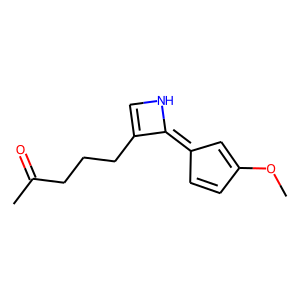

In [ ]:
draw_compound(augmented)

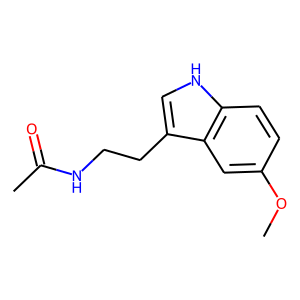

In [ ]:
draw_compound(original)

In [ ]:
similarity(original, augmented)

0.31746031746031744

In [ ]:
# imports

import keras
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras import backend as K

In [ ]:
!pip install fastapi

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 54 kB 2.2 MB/s 
     |████████████████████████████████| 63 kB 2.1 MB/s 
     |████████████████████████████████| 80 kB 10.8 MB/s 


In [ ]:
!pip install uvicorn

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 57 kB 3.0 MB/s 
     |████████████████████████████████| 58 kB 6.9 MB/s 


In [ ]:
pip install scipy

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
%%file main.py
from typing import Optional
from fastapi import FastAPI

app = FastAPI()
@app.route('/')
def index_view():
    return render_template('index.html')


@app.route('/predict/',methods=['GET','POST'])
def predict():
	response = "For ML Prediction"
return response	

if __name__ == '__main__':
    app.run(debug=True, port=8000)

Overwriting main.py


In [ ]:
from flask import Flask, render_template, request
from scipy.misc import imsave, imread, imresize
import numpy as np
import keras.models
import re
import sys 
import os
import base64
sys.path.append(os.path.abspath("./model"))
from load import * 


global graph, model

model, graph = init()

app = Flask(__name__)


@app.route('/')
def index_view():
    return render_template('index.html')

def convertImage(imgData1):
	imgstr = re.search(b'base64,(.*)',imgData1).group(1)
	with open('output.png','wb') as output:
	    output.write(base64.b64decode(imgstr))

@app.route('/predict/',methods=['GET','POST'])
def predict():
	imgData = request.get_data()
	convertImage(imgData)
	x = imread('output.png',mode='L')
	x = np.invert(x)
	x = imresize(x,(28,28))
	x = x.reshape(1,28,28,1)

	with graph.as_default():
		out = model.predict(x)
		print(out)
		print(np.argmax(out,axis=1))

		response = np.array_str(np.argmax(out,axis=1))
		return response	

if __name__ == '__main__':
    app.run(debug=True, port=8000)

ImportError: ignored